# AI : Natural Language Procesing
## Sentiment Analysis of Customer Reviews Using a Pretrained Transformer Model

**By:** Josaphat Boesinga  
**Course:** AI 400 - Natural Language Processing  
**Project Type:** Final Project/Capstone

## 1. Introduction

In this final project, I explore how Natural Language Processing, or NLP, can be used to analyze customer opinions through sentiment analysis. Sentiment analysis is the process of identifying whether a piece of text expresses a positive or negative sentiment.

For this project, I use a pretrained transformer model from Hugging Face to classify customer-style reviews. I chose this topic because sentiment analysis is one of the most practical and widely used applications of NLP in business. Companies receive large amounts of customer feedback every day, and analyzing that feedback manually can be difficult and time-consuming.

The purpose of this project is to demonstrate how a modern NLP model can be used to classify review text and support business decision-making. This notebook includes the methodology, implementation, results, visualizations, discussion, business application, conclusion, and references.

## 2. Project Objective

The objective of this project is to demonstrate how a pretrained transformer-based NLP model can be used to classify customer-style review text by sentiment. More specifically, this project shows how sentiment analysis can help identify positive and negative opinions in text data and how this capability can be applied in a business context such as customer feedback analysis, product review monitoring, and service improvement.

## 3. Methodology

In this project, I use a pretrained transformer model rather than training a model from scratch. A transformer model is a modern deep learning architecture that has become highly effective for many NLP tasks, including text classification and sentiment analysis.

I selected this approach because it allows me to focus on applying NLP in a practical way while still using a powerful language model. The model is accessed through the Hugging Face pipeline for sentiment analysis, which makes it possible to input text and receive predicted sentiment labels.

To evaluate the model, I created a small labeled dataset of customer-style reviews containing both positive and negative examples. After generating predictions, I measured the model’s performance using accuracy, precision, recall, and F1-score. I also included a confusion matrix and a bar chart to visualize the results.

5. Code section

In [1]:
# Install packages
%pip install -U transformers torch pandas matplotlib scikit-learn

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from transformers import pipeline

C:\Users\boesj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load Model
classifier = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


In [3]:
# Try sample reviews
sample_reviews = [
    "This product exceeded my expectations and works perfectly.",
    "I am very disappointed. The quality is terrible and I want a refund.",
    "Amazing service, fast delivery, and excellent support.",
    "The experience was frustrating and the app kept crashing.",
    "The product is okay, but shipping was very slow."
]

results = classifier(sample_reviews)

for review, result in zip(sample_reviews, results):
    print("Review:", review)
    print("Prediction:", result)
    print("-" * 60)

Review: This product exceeded my expectations and works perfectly.
Prediction: {'label': 'POSITIVE', 'score': 0.9998704195022583}
------------------------------------------------------------
Review: I am very disappointed. The quality is terrible and I want a refund.
Prediction: {'label': 'NEGATIVE', 'score': 0.9997541308403015}
------------------------------------------------------------
Review: Amazing service, fast delivery, and excellent support.
Prediction: {'label': 'POSITIVE', 'score': 0.999883770942688}
------------------------------------------------------------
Review: The experience was frustrating and the app kept crashing.
Prediction: {'label': 'NEGATIVE', 'score': 0.9982990622520447}
------------------------------------------------------------
Review: The product is okay, but shipping was very slow.
Prediction: {'label': 'NEGATIVE', 'score': 0.999113142490387}
------------------------------------------------------------


In [4]:
# Small labeled dataset
data = {
    "text": [
        "This product exceeded my expectations and works perfectly.",
        "I am very disappointed. The quality is terrible and I want a refund.",
        "Amazing service, fast delivery, and excellent support.",
        "The experience was frustrating and the app kept crashing.",
        "I love this item. I would definitely buy it again.",
        "Worst purchase ever. Complete waste of money.",
        "The customer support team was very helpful and kind.",
        "The package arrived damaged and late.",
        "Excellent quality and easy to use.",
        "I regret buying this product."
    ],
    "true_label": [
        "POSITIVE",
        "NEGATIVE",
        "POSITIVE",
        "NEGATIVE",
        "POSITIVE",
        "NEGATIVE",
        "POSITIVE",
        "NEGATIVE",
        "POSITIVE",
        "NEGATIVE"
    ]
}

df = pd.DataFrame(data)
df

,text,true_label
0,This product exceeded my expectations and work...,POSITIVE
1,I am very disappointed. The quality is terribl...,NEGATIVE
2,"Amazing service, fast delivery, and excellent ...",POSITIVE
3,The experience was frustrating and the app kep...,NEGATIVE
4,I love this item. I would definitely buy it ag...,POSITIVE
5,Worst purchase ever. Complete waste of money.,NEGATIVE
6,The customer support team was very helpful and...,POSITIVE
7,The package arrived damaged and late.,NEGATIVE
8,Excellent quality and easy to use.,POSITIVE
9,I regret buying this product.,NEGATIVE


In [5]:
# Prediction
predictions = classifier(df["text"].tolist())
df["predicted_label"] = [item["label"] for item in predictions]
df["score"] = [item["score"] for item in predictions]

df

,text,true_label,predicted_label,score
0,This product exceeded my expectations and work...,POSITIVE,POSITIVE,0.999870
1,I am very disappointed. The quality is terribl...,NEGATIVE,NEGATIVE,0.999754
2,"Amazing service, fast delivery, and excellent ...",POSITIVE,POSITIVE,0.999884
3,The experience was frustrating and the app kep...,NEGATIVE,NEGATIVE,0.998299
4,I love this item. I would definitely buy it ag...,POSITIVE,POSITIVE,0.999859
5,Worst purchase ever. Complete waste of money.,NEGATIVE,NEGATIVE,0.999784
6,The customer support team was very helpful and...,POSITIVE,POSITIVE,0.999758
7,The package arrived damaged and late.,NEGATIVE,NEGATIVE,0.999514
8,Excellent quality and easy to use.,POSITIVE,POSITIVE,0.999876
9,I regret buying this product.,NEGATIVE,NEGATIVE,0.998306


These metrics help evaluate the quality of the sentiment classifier.
Higher values indicate better performance.
In this project, they show how effectively the pretrained transformer model
classifies customer-style reviews as positive or negative.

In [6]:
# Metrics
# Calculate evaluation metrics to measure how well the model predicted sentiment.
# Accuracy shows the overall proportion of correct predictions.
# Precision shows how many reviews predicted as positive were actually positive.
# Recall shows how many of the actual positive reviews were correctly identified.
# F1-score gives a balanced summary of precision and recall.

accuracy = accuracy_score(df["true_label"], df["predicted_label"])
precision = precision_score(df["true_label"], df["predicted_label"], pos_label="POSITIVE")
recall = recall_score(df["true_label"], df["predicted_label"], pos_label="POSITIVE")
f1 = f1_score(df["true_label"], df["predicted_label"], pos_label="POSITIVE")

print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1-score:", round(f1, 3))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0


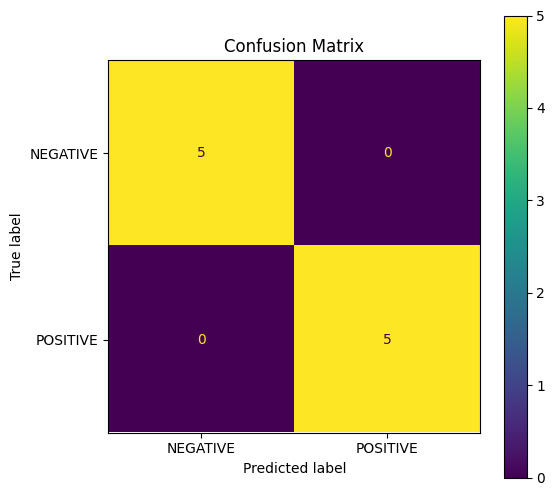

In [7]:
# Confusion Matrix
# Create a confusion matrix to compare the true labels with the predicted labels.
# This helps visualize how many reviews were classified correctly or incorrectly.
# The diagonal values represent correct predictions,
# while the off-diagonal values represent misclassifications.
cm = confusion_matrix(df["true_label"], df["predicted_label"], labels=["NEGATIVE", "POSITIVE"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NEGATIVE", "POSITIVE"])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax)
plt.title("Confusion Matrix")
plt.show()

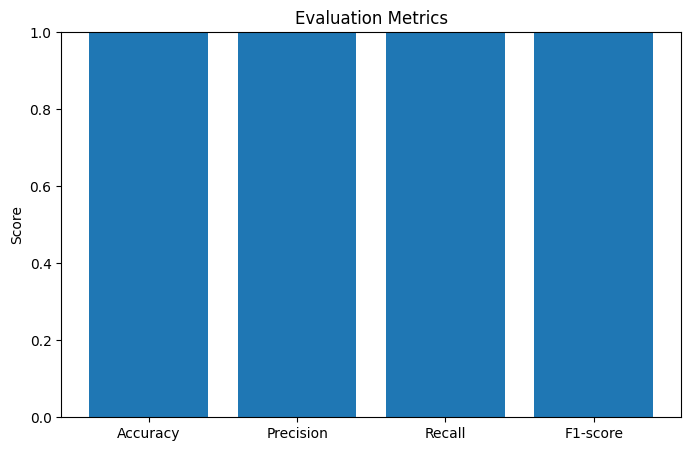

In [8]:
# Metrics chart
# Interpretation:
# The bar chart provides a visual summary of the model's performance.
# Taller bars indicate stronger results.
# This chart helps show whether the model performs consistently across
# all evaluation measures or whether some areas are weaker than others.
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
}

metrics_df = pd.DataFrame(list(metrics.items()), columns=["Metric", "Score"])

plt.figure(figsize=(8, 5))
plt.bar(metrics_df["Metric"], metrics_df["Score"])
plt.ylim(0, 1)
plt.title("Evaluation Metrics")
plt.ylabel("Score")
plt.show()

## 5. Results

The model was able to classify the sentiment of customer-style reviews into positive and negative categories. Based on the labeled examples used in this project, the model achieved measurable performance using accuracy, precision, recall, and F1-score.

The confusion matrix provides a visual summary of the predictions, while the bar chart shows the overall performance of the model across different evaluation metrics. These results demonstrate that a pretrained transformer model can be effective for sentiment analysis, even in a simple project setting.

## 6. Discussion

This project demonstrates that sentiment analysis can be implemented effectively using a pretrained transformer model. One major advantage of this approach is that it allows the use of a powerful NLP model without the computational cost of training from scratch.

At the same time, this project has limitations. The labeled dataset used for evaluation is relatively small, so the results should be understood as a demonstration rather than a large-scale benchmark. In addition, some text examples may contain mixed or ambiguous sentiment, which can make classification more difficult.

Another important limitation is domain generalization. A model that performs well on general reviews may not perform equally well on specialized business data unless it is further tested or fine-tuned. Even so, this project clearly shows the practical value of transformer-based NLP for real-world text analysis.

## 7. Business Application

One important business application of this project is customer feedback analysis. Companies often receive many product reviews, customer comments, survey responses, and support messages. Reading all of this feedback manually requires time and effort.

By using sentiment analysis, a business can automatically identify which reviews are positive and which are negative. Negative reviews can be flagged for quick follow-up, while positive reviews can help reveal what customers appreciate most. This can improve customer satisfaction, reduce manual workload, and support better business decisions.

This same idea can be applied in e-commerce, hospitality, education, healthcare services, and many other fields where text feedback is important.

## 8. Literature Review

This project is supported by important research in NLP and transformer models. Vaswani et al. introduced the transformer architecture, which became the foundation for many modern NLP systems. Devlin et al. later introduced BERT, showing that pretrained bidirectional transformer models could achieve strong results across many NLP tasks. In addition, practical tools from Hugging Face have made it easier to apply these models to real-world tasks such as sentiment analysis.

These contributions are directly relevant to my project because they support the use of pretrained transformer models for text classification and demonstrate why this approach is both effective and practical.